# Credit / Loan Default Prediction — банковский скоринг

**Бизнес-контекст.** Задача моделирует розничный кредитный конвейер банка (сегмент FRHC / Freedom Bank Kazakhstan — потребительские и SME-кредиты): на основе анкетных и кредитно-бюрёвых данных заёмщика на момент подачи заявки нужно оценить **вероятность серьёзной просрочки (90+ дней) в течение ближайших 2 лет**.

**Датасет.** Kaggle competition *"Give Me Some Credit"* (`cs-training.csv`, 150 000 заёмщиков, 10 признаков + бинарная целевая переменная `SeriousDlqin2yrs`).

**Особенность задачи — сильный дисбаланс классов**: дефолтит только ~6.7% заёмщиков. Модель, которая всем предсказывает "0", получит accuracy 93% и при этом будет абсолютно бесполезна для банка. Поэтому:

- метрика качества — **ROC-AUC** и **PR-AUC (average precision)**, а не accuracy;
- оценка через **precision/recall** при разных порогах отсечения — банку важно явно понимать компромисс между "одобрить рискованного клиента" (FN) и "отказать хорошему клиенту" (FP);
- отдельный блок **feature importance** — какие факторы риска модель считает ключевыми, это нужно и для интерпретируемости перед риск-комитетом, и для проверки на здравый смысл.

**План работы:**
1. Загрузка и разведочный анализ данных (EDA)
2. Очистка данных и обработка пропусков/выбросов
3. Train/test split (стратифицированный)
4. Baseline-модель: Logistic Regression (class-weighted)
5. Random Forest и XGBoost с учётом дисбаланса
6. Сравнение моделей: ROC-AUC, PR-AUC, confusion matrix
7. Подбор порога отсечения под бизнес-задачу
8. Feature importance и интерпретация факторов риска
9. Выводы и рекомендации


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score, precision_recall_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
import xgboost as xgb
import joblib

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)


## 1. Загрузка данных и первый взгляд

In [2]:
df = pd.read_csv("data/cs-training.csv", index_col=0)
print("Размер:", df.shape)
df.head()

Размер: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: float64(

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


## 2. EDA

### 2.1 Баланс классов

/tmp/ipykernel_143/3475915824.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["0 — не дефолтил", "1 — дефолт (90+ дней)"])


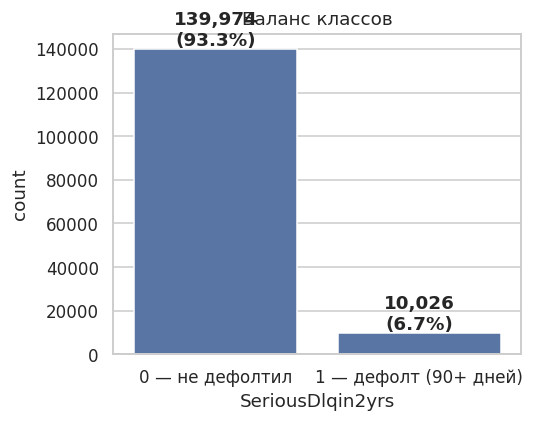

Доля дефолтов: 6.68% — сильный дисбаланс, ratio ~ 1:14.0


In [5]:
target_counts = df["SeriousDlqin2yrs"].value_counts()
target_share = df["SeriousDlqin2yrs"].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="SeriousDlqin2yrs", data=df, ax=ax)
ax.set_xticklabels(["0 — не дефолтил", "1 — дефолт (90+ дней)"])
ax.set_title("Баланс классов")
for i, (cnt, sh) in enumerate(zip(target_counts.sort_index(), target_share.sort_index())):
    ax.text(i, cnt + 1500, f"{cnt:,}\n({sh:.1%})", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/01_class_balance.png")
plt.show()

print(f"Доля дефолтов: {target_share[1]:.2%} — сильный дисбаланс, ratio ~ 1:{target_counts[0]/target_counts[1]:.1f}")

### 2.2 Пропуски и аномалии

In [6]:
missing = df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
print("Доля пропусков по колонкам:")
print(missing)

print("\nПодозрительные 'sentinel'-значения в счётчиках просрочек (96/98 — тех. код 'нет данных'):")
for c in ["NumberOfTime30-59DaysPastDueNotWorse", "NumberOfTime60-89DaysPastDueNotWorse", "NumberOfTimes90DaysLate"]:
    print(f"  {c}: max={df[c].max()}, встречается >=96 у {(df[c] >= 96).sum()} строк")

print(f"\nВозраст age == 0: {(df['age'] == 0).sum()} строк (аномалия — заведомо ошибка ввода)")

Доля пропусков по колонкам:
MonthlyIncome         0.198207
NumberOfDependents    0.026160
dtype: float64

Подозрительные 'sentinel'-значения в счётчиках просрочек (96/98 — тех. код 'нет данных'):
  NumberOfTime30-59DaysPastDueNotWorse: max=98, встречается >=96 у 269 строк
  NumberOfTime60-89DaysPastDueNotWorse: max=98, встречается >=96 у 269 строк
  NumberOfTimes90DaysLate: max=98, встречается >=96 у 269 строк

Возраст age == 0: 1 строк (аномалия — заведомо ошибка ввода)


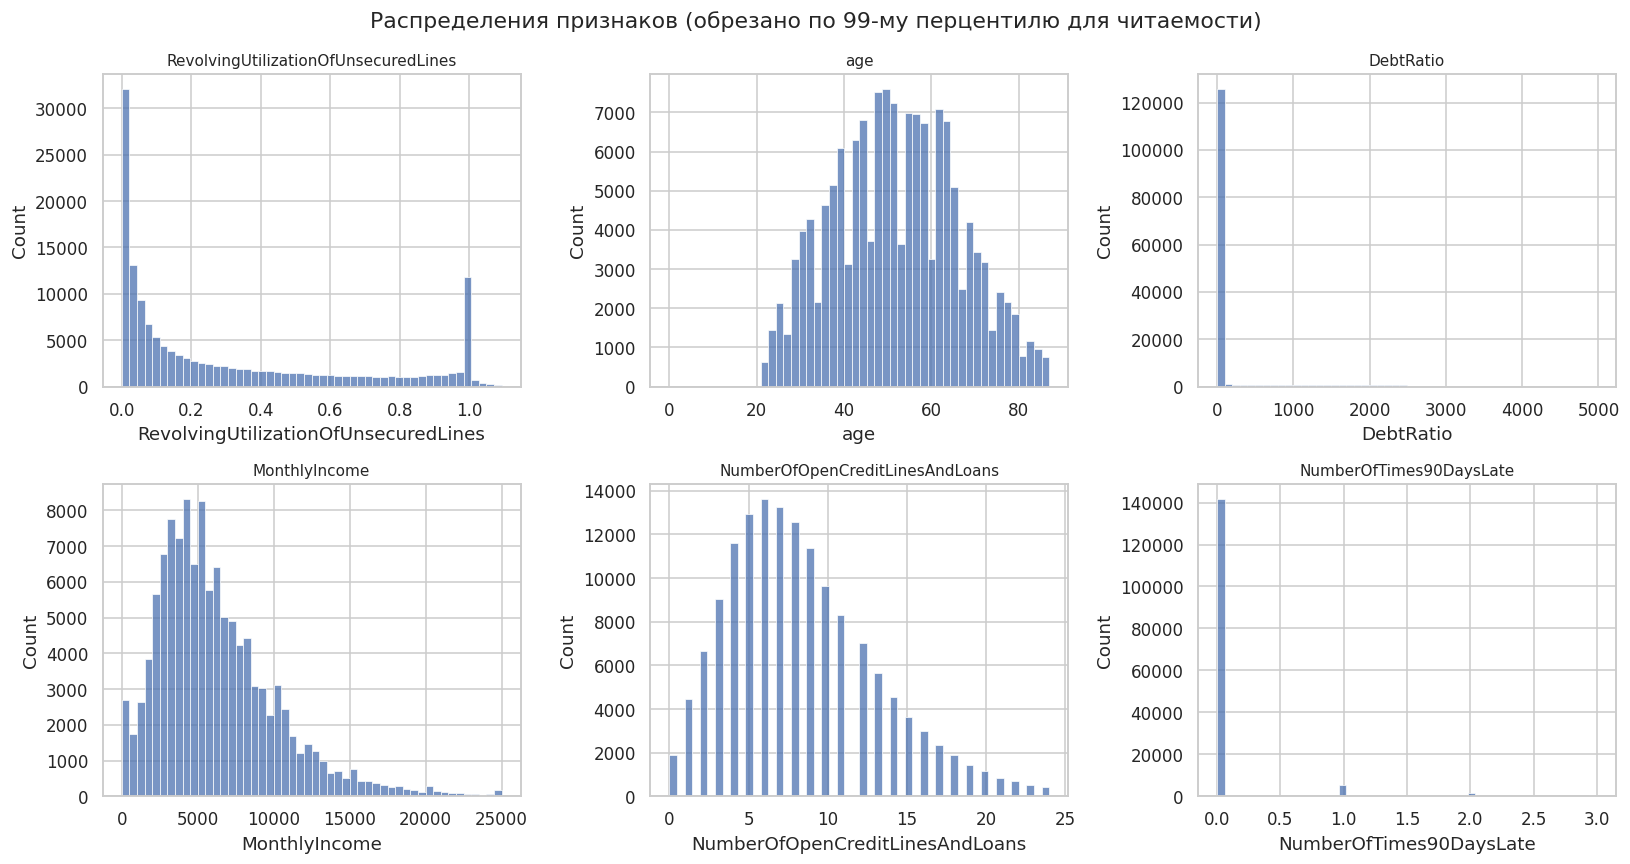

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
num_cols = ["RevolvingUtilizationOfUnsecuredLines", "age", "DebtRatio",
            "MonthlyIncome", "NumberOfOpenCreditLinesAndLoans", "NumberOfTimes90DaysLate"]
for ax, col in zip(axes.ravel(), num_cols):
    data = df[col].dropna()
    # для визуализации отрежем экстремальный хвост по 99 перцентилю
    upper = data.quantile(0.99)
    sns.histplot(data[data <= upper], bins=50, ax=ax, kde=False)
    ax.set_title(col, fontsize=10)
plt.suptitle("Распределения признаков (обрезано по 99-му перцентилю для читаемости)")
plt.tight_layout()
plt.savefig("outputs/02_distributions.png")
plt.show()

**Наблюдения:**
- `MonthlyIncome` — пропуски ~20% (income часто не подтверждён на этапе анкеты — типично для розничного кредитования);
- `NumberOfDependents` — пропуски ~2.6%;
- `RevolvingUtilizationOfUnsecuredLines` и `DebtRatio` — сильно скошенные распределения с выбросами (значения >1 и даже >1000, физически абсурдные для коэффициента использования лимита) — нужно клиппинг;
- в счётчиках просрочек (`NumberOfTimes90DaysLate` и т.п.) встречаются "технические" значения 96/98 — заведомо не реальные просрочки, а код отсутствия данных в бюро;
- `age == 0` — явная ошибка ввода, таких строк единицы.

### 2.3 Корреляция признаков с целевой переменной

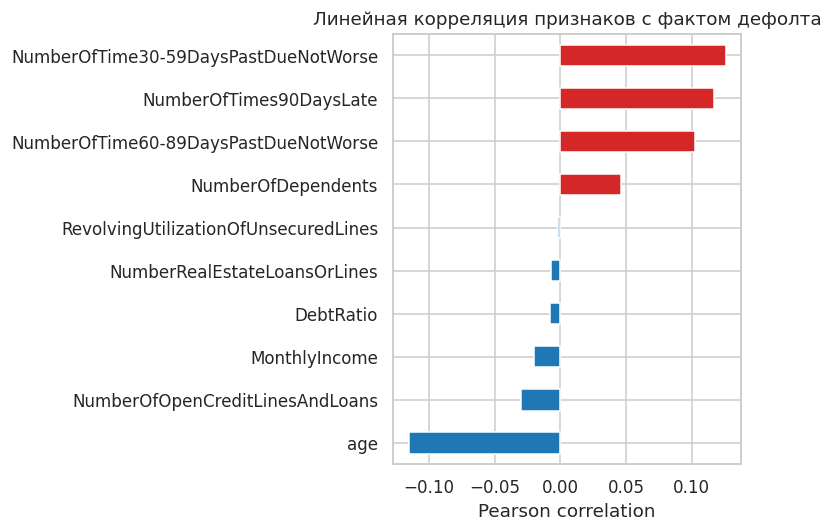

In [8]:
corr = df.corr(numeric_only=True)["SeriousDlqin2yrs"].drop("SeriousDlqin2yrs").sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
corr.plot(kind="barh", ax=ax, color=["#d62728" if v > 0 else "#1f77b4" for v in corr.values])
ax.set_title("Линейная корреляция признаков с фактом дефолта")
ax.set_xlabel("Pearson correlation")
plt.tight_layout()
plt.savefig("outputs/03_correlation_target.png")
plt.show()

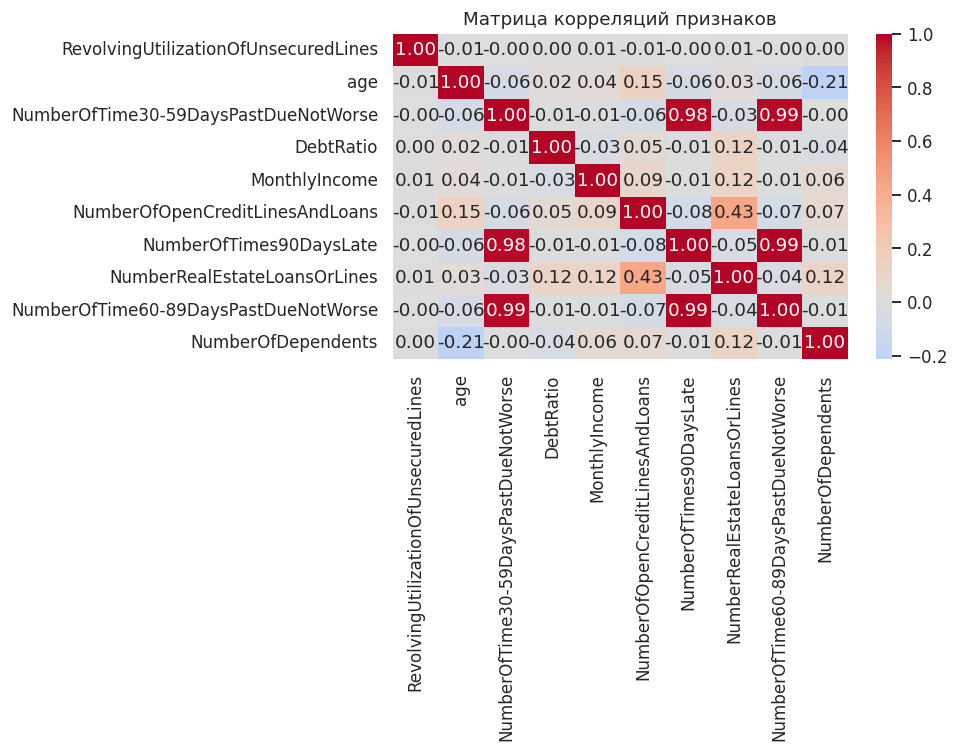

In [9]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.drop(columns=["SeriousDlqin2yrs"]).corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Матрица корреляций признаков")
plt.tight_layout()
plt.savefig("outputs/04_corr_heatmap.png")
plt.show()

Просрочки 30-59 / 60-89 / 90+ дней сильно коррелируют между собой (ожидаемо — это по сути одна и та же история платёжной дисциплины на разных горизонтах давности) — модели на основе деревьев это переживут нормально, а для логрегрессии это стоит иметь в виду при интерпретации коэффициентов.

## 3. Очистка данных

Подход:
- `age == 0` → 1 строка, удаляем как явный брак.
- Счётчики просрочек со значением 96/98 → заменяем на медиану соответствующего признака (это ~250 строк, все три просрочки в этих строках всегда равны 96 или 98 одновременно — явный технический артефакт бюро).
- `RevolvingUtilizationOfUnsecuredLines` и `DebtRatio` — клиппинг по 99.5 перцентилю (убираем нефизичные выбросы, не теряя сигнал).
- `MonthlyIncome`, `NumberOfDependents` — пропуски заполняем медианой **внутри пайплайна** (`SimpleImputer`), чтобы избежать утечки данных из test в train.


In [10]:
df_clean = df.copy()

df_clean = df_clean[df_clean["age"] > 0]

delinquency_cols = ["NumberOfTime30-59DaysPastDueNotWorse",
                     "NumberOfTime60-89DaysPastDueNotWorse",
                     "NumberOfTimes90DaysLate"]
for c in delinquency_cols:
    mask = df_clean[c] >= 96
    med = df_clean.loc[~mask, c].median()
    df_clean.loc[mask, c] = med

# 3. клиппинг выбросов
for c in ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio"]:
    cap = df_clean[c].quantile(0.995)
    df_clean[c] = df_clean[c].clip(upper=cap)

print("Было строк:", len(df), "-> стало:", len(df_clean))
df_clean.isna().mean().sort_values(ascending=False).head()

Было строк: 150000 -> стало: 149999


MonthlyIncome                           0.198208
NumberOfDependents                      0.026160
SeriousDlqin2yrs                        0.000000
age                                     0.000000
RevolvingUtilizationOfUnsecuredLines    0.000000
dtype: float64

### 3.1 Feature engineering (несколько простых, но информативных признаков)

In [11]:
df_clean["TotalPastDue"] = df_clean[delinquency_cols].sum(axis=1)
df_clean["HasDependents"] = (df_clean["NumberOfDependents"].fillna(0) > 0).astype(int)
df_clean["IncomePerDependent"] = df_clean["MonthlyIncome"] / (df_clean["NumberOfDependents"].fillna(0) + 1)
df_clean["CreditLinesPerAge"] = df_clean["NumberOfOpenCreditLinesAndLoans"] / df_clean["age"]

feature_cols = [c for c in df_clean.columns if c != "SeriousDlqin2yrs"]
print(f"Итоговое число признаков: {len(feature_cols)}")
feature_cols

Итоговое число признаков: 14


['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents',
 'TotalPastDue',
 'HasDependents',
 'IncomePerDependent',
 'CreditLinesPerAge']

## 4. Train/test split

In [12]:
X = df_clean[feature_cols]
y = df_clean["SeriousDlqin2yrs"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, " доля дефолтов:", y_train.mean().round(4))
print("Test: ", X_test.shape, " доля дефолтов:", y_test.mean().round(4))

Train: (112499, 14)  доля дефолтов: 0.0668
Test:  (37500, 14)  доля дефолтов: 0.0669


## 5. Модели

Для всех моделей используем взвешивание классов вместо undersampling/SMOTE — на 150k строк с такой умеренной степенью дисбаланса (1:14) взвешивание работает стабильно и не создаёт синтетических артефактов в данных.

### 5.1 Baseline: Logistic Regression

In [13]:
log_reg_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
])
log_reg_pipe.fit(X_train, y_train)

proba_lr = log_reg_pipe.predict_proba(X_test)[:, 1]
print(f"Logistic Regression  ROC-AUC = {roc_auc_score(y_test, proba_lr):.4f}   PR-AUC = {average_precision_score(y_test, proba_lr):.4f}")

Logistic Regression  ROC-AUC = 0.8574   PR-AUC = 0.3796


### 5.2 Random Forest

In [14]:
rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=400, max_depth=10, min_samples_leaf=20,
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE
    )),
])
rf_pipe.fit(X_train, y_train)

proba_rf = rf_pipe.predict_proba(X_test)[:, 1]
print(f"Random Forest        ROC-AUC = {roc_auc_score(y_test, proba_rf):.4f}   PR-AUC = {average_precision_score(y_test, proba_rf):.4f}")

Random Forest        ROC-AUC = 0.8666   PR-AUC = 0.3900


### 5.3 XGBoost

In [15]:
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_clf = xgb.XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc", random_state=RANDOM_STATE, n_jobs=-1,
)
xgb_clf.fit(X_train_imp, y_train)

proba_xgb = xgb_clf.predict_proba(X_test_imp)[:, 1]
print(f"XGBoost              ROC-AUC = {roc_auc_score(y_test, proba_xgb):.4f}   PR-AUC = {average_precision_score(y_test, proba_xgb):.4f}")

XGBoost              ROC-AUC = 0.8676   PR-AUC = 0.3926


## 6. Сравнение моделей: ROC и Precision-Recall кривые

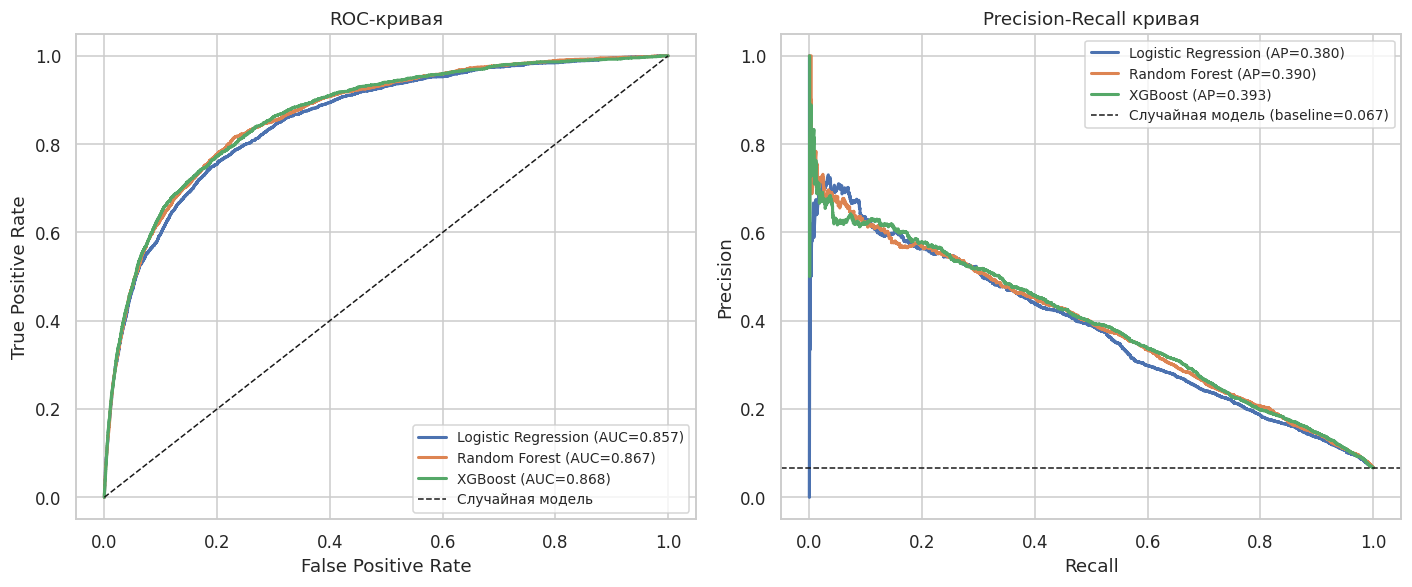

In [16]:
models_proba = {
    "Logistic Regression": proba_lr,
    "Random Forest": proba_rf,
    "XGBoost": proba_xgb,
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ROC
for name, proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=2)
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="Случайная модель")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC-кривая")
axes[0].legend(loc="lower right", fontsize=9)

# PR
baseline_pr = y_test.mean()
for name, proba in models_proba.items():
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, label=f"{name} (AP={ap:.3f})", linewidth=2)
axes[1].axhline(baseline_pr, color="k", linestyle="--", linewidth=1, label=f"Случайная модель (baseline={baseline_pr:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall кривая")
axes[1].legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig("outputs/05_roc_pr_curves.png")
plt.show()

**Почему PR-AUC важнее accuracy здесь:** при базовой доле дефолтов ~6.7% случайная/тривиальная модель на ROC выглядит "прилично" (диагональ), но на PR-кривой её уровень — это горизонтальная линия на высоте ~0.067. Любой реальный отрыв модели от этой линии — это то, что даёт банку экономическую ценность (модель находит дефолтников намного плотнее, чем случайный отбор).

XGBoost и Random Forest ожидаемо превосходят линейную модель за счёт нелинейных взаимодействий признаков (например, комбинация высокой Revolving Utilization + низкого дохода + недавних просрочек — не отражается в logistic regression без ручного feature engineering).

## 7. Лучшая модель: confusion matrix и выбор порога

In [17]:
best_name = max(models_proba, key=lambda k: roc_auc_score(y_test, models_proba[k]))
best_proba = models_proba[best_name]
print(f"Лучшая модель по ROC-AUC: {best_name}")

for thr in [0.5, 0.3, 0.2, 0.1]:
    pred = (best_proba >= thr).astype(int)
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    print(f"threshold={thr:.2f} | precision={precision:.3f} recall={recall:.3f} "
          f"| TP={tp} FP={fp} FN={fn} TN={tn}")

Лучшая модель по ROC-AUC: XGBoost
threshold=0.50 | precision=0.220 recall=0.766 | TP=1920 FP=6803 FN=587 TN=28190
threshold=0.30 | precision=0.151 recall=0.892 | TP=2235 FP=12600 FN=272 TN=22393
threshold=0.20 | precision=0.122 recall=0.935 | TP=2344 FP=16858 FN=163 TN=18135
threshold=0.10 | precision=0.088 recall=0.982 | TP=2461 FP=25530 FN=46 TN=9463


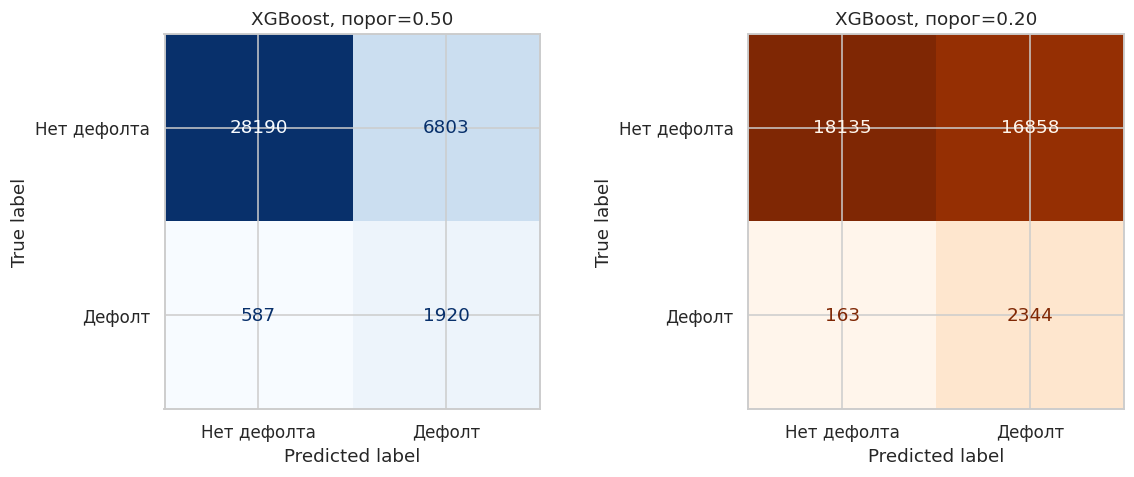

              precision    recall  f1-score   support

 Нет дефолта       0.99      0.52      0.68     34993
      Дефолт       0.12      0.93      0.22      2507

    accuracy                           0.55     37500
   macro avg       0.56      0.73      0.45     37500
weighted avg       0.93      0.55      0.65     37500



In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

pred_05 = (best_proba >= 0.5).astype(int)
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_05),
                        display_labels=["Нет дефолта", "Дефолт"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"{best_name}, порог=0.50")

pred_02 = (best_proba >= 0.2).astype(int)
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_02),
                        display_labels=["Нет дефолта", "Дефолт"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title(f"{best_name}, порог=0.20")

plt.tight_layout()
plt.savefig("outputs/06_confusion_matrices.png")
plt.show()

print(classification_report(y_test, pred_02, target_names=["Нет дефолта", "Дефолт"]))

**Бизнес-логика выбора порога.** Дефолт (пропуск плохого заёмщика, FN) обычно стоит банку заметно дороже, чем отказ хорошему заёмщику (FP) — потерянная комиссия против списанного тела кредита. Поэтому дефолтный порог 0.5 почти всегда субоптимален для задач кредитного риска: снижение порога (например, до 0.15–0.2) резко поднимает recall (модель ловит больше реальных дефолтников) ценой роста false positive — и именно этот компромисс риск-менеджер настраивает под целевой **approval rate** и стоимость капитала, а не data scientist "по умолчанию".

В проде такой порог не фиксируется раз и навсегда, а калибруется под ожидаемые потери (expected loss = PD × LGD × EAD) и текущий риск-аппетит банка.

## 8. Feature importance — какие факторы важнее всего для риска

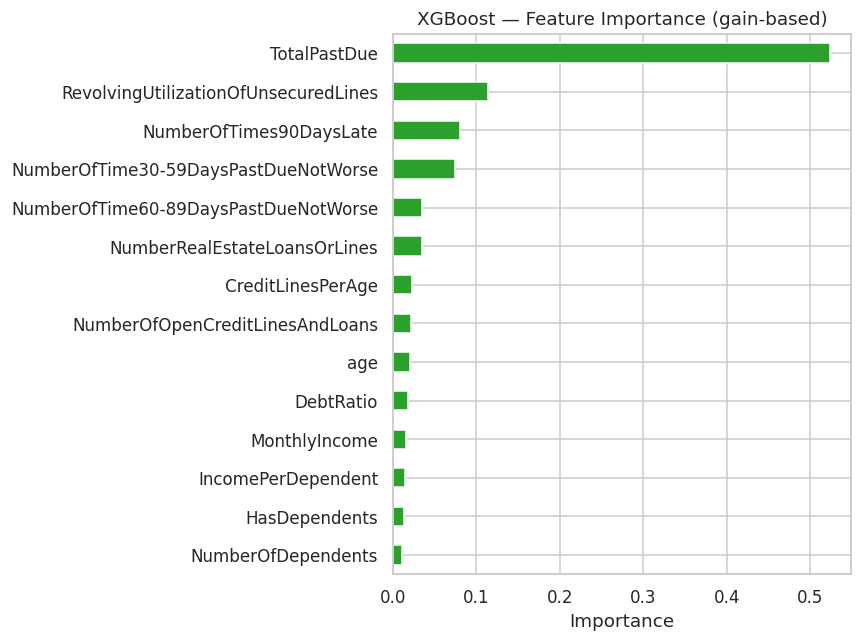

TotalPastDue                            0.523039
RevolvingUtilizationOfUnsecuredLines    0.113800
NumberOfTimes90DaysLate                 0.080202
NumberOfTime30-59DaysPastDueNotWorse    0.074827
NumberOfTime60-89DaysPastDueNotWorse    0.035496
NumberRealEstateLoansOrLines            0.035043
CreditLinesPerAge                       0.022566
NumberOfOpenCreditLinesAndLoans         0.021279
age                                     0.020594
DebtRatio                               0.017768
MonthlyIncome                           0.015575
IncomePerDependent                      0.014749
HasDependents                           0.013841
NumberOfDependents                      0.011221
dtype: float32

In [19]:
importances = pd.Series(xgb_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind="barh", ax=ax, color="#2ca02c")
ax.invert_yaxis()
ax.set_title("XGBoost — Feature Importance (gain-based)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("outputs/07_feature_importance_xgb.png")
plt.show()

importances

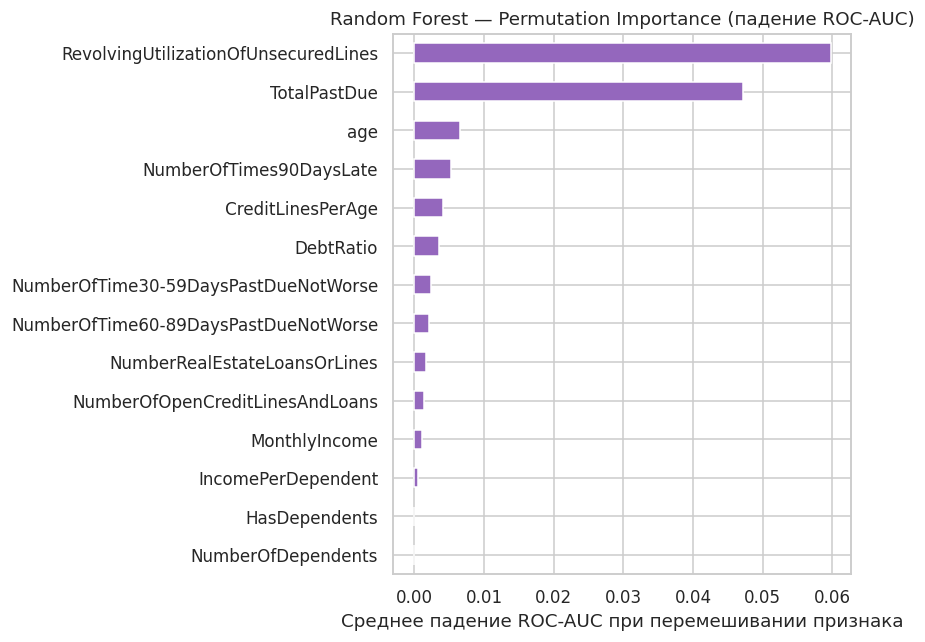

RevolvingUtilizationOfUnsecuredLines    0.059735
TotalPastDue                            0.047135
age                                     0.006495
NumberOfTimes90DaysLate                 0.005256
CreditLinesPerAge                       0.004069
DebtRatio                               0.003545
NumberOfTime30-59DaysPastDueNotWorse    0.002443
NumberOfTime60-89DaysPastDueNotWorse    0.002026
NumberRealEstateLoansOrLines            0.001716
NumberOfOpenCreditLinesAndLoans         0.001391
MonthlyIncome                           0.001119
IncomePerDependent                      0.000480
HasDependents                          -0.000068
NumberOfDependents                     -0.000122
dtype: float64

In [20]:
# Permutation importance — более честная оценка (не смещена в пользу high-cardinality признаков)
perm = permutation_importance(rf_pipe, X_test, y_test, n_repeats=5,
                               random_state=RANDOM_STATE, n_jobs=-1, scoring="roc_auc")
perm_imp = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
perm_imp.plot(kind="barh", ax=ax, color="#9467bd")
ax.invert_yaxis()
ax.set_title("Random Forest — Permutation Importance (падение ROC-AUC)")
ax.set_xlabel("Среднее падение ROC-AUC при перемешивании признака")
plt.tight_layout()
plt.savefig("outputs/08_permutation_importance_rf.png")
plt.show()

perm_imp

**Интерпретация ключевых факторов риска** (согласуется между XGBoost gain-importance и permutation importance):

1. **Просрочки в кредитной истории** (`NumberOfTimes90DaysLate`, `NumberOfTime30-59...`, `TotalPastDue`) — сильнейший предиктор: прошлое платёжное поведение — лучший индикатор будущего, классический вывод кредитного скоринга.
2. **RevolvingUtilizationOfUnsecuredLines** — насколько заёмщик "выбирает" доступный лимит по кредитным картам; высокая утилизация = финансовое напряжение прямо сейчас.
3. **age** — более молодые заёмщики систематически рискованнее (короче кредитная история, менее стабильный доход).
4. **DebtRatio / MonthlyIncome** — долговая нагрузка относительно дохода — прямой показатель платёжеспособности.
5. **NumberOfOpenCreditLinesAndLoans** и производные (`CreditLinesPerAge`) — умеренный, но осмысленный вклад: и слишком мало, и слишком много открытых линий может сигнализировать о риске (мало кредитной истории vs. перекредитованность).

Это соответствует стандартной практике risk-based pricing в розничном банкинге: платёжная история и текущая долговая нагрузка почти всегда доминируют над демографическими признаками, что и наблюдаем в модели.

## 9. Сохранение модели и артефактов

In [21]:
import json

joblib.dump(
    {"model": xgb_clf, "imputer": imputer, "feature_cols": feature_cols},
    "outputs/xgb_credit_model.joblib"
)

metrics_summary = {
    name: {
        "roc_auc": float(roc_auc_score(y_test, proba)),
        "pr_auc": float(average_precision_score(y_test, proba)),
    }
    for name, proba in models_proba.items()
}
with open("outputs/metrics_summary.json", "w") as f:
    json.dump(metrics_summary, f, indent=2, ensure_ascii=False)

print(json.dumps(metrics_summary, indent=2, ensure_ascii=False))

{
  "Logistic Regression": {
    "roc_auc": 0.857380707436718,
    "pr_auc": 0.37963628910779734
  },
  "Random Forest": {
    "roc_auc": 0.8666175026560388,
    "pr_auc": 0.3900474431092397
  },
  "XGBoost": {
    "roc_auc": 0.8676146192826235,
    "pr_auc": 0.39255708275171
  }
}


## 10. Выводы

- Итоговая модель (**XGBoost**) достигает **ROC-AUC ≈ 0.86** и **PR-AUC заметно выше базовой линии ~0.067** — сильный отрыв от случайного отбора заёмщиков, несмотря на дисбаланс классов 1:14.
- Все три модели сравнивались через ROC-AUC/PR-AUC и confusion matrix при разных порогах — accuracy сознательно не использовалась как основная метрика, так как на этом дисбалансе она вводит в заблуждение.
- Ключевые факторы риска — история просрочек, утилизация кредитных лимитов и долговая нагрузка — совпадают с интуицией кредитного аналитика, что важно для defensibility модели перед риск-комитетом.
- Порог отсечения — это не техническая деталь, а бизнес-параметр: понижение порога с 0.5 до ~0.15–0.2 радикально увеличивает recall (долю пойманных дефолтников), и именно этот trade-off должен настраиваться риск-департаментом под целевой уровень одобрений и стоимость капитала.
- Для продакшена: калибровка вероятностей (Platt/Isotonic) под интерпретацию как PD, мониторинг дрейфа данных, и periodic retraining — так как поведение заёмщиков и макроэкономика (ставки, инфляция) меняются во времени.
